Feature Engineering

In [6]:
import nltk
import re
import os
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
nltk.download('wordnet')
!pip install pandas python-docx pdfplumber
print(os.getcwd())

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\nutan\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\nutan\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\nutan\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nutan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\nutan\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


C:\Users\nutan\Projects\Resume Classification Project


In [9]:
import os
import pandas as pd
import pdfplumber
from docx import Document

# Root folder containing the 4 category folders
root_folder = r"C:\Users\nutan\Projects\Resume Classification Project\Resumes"

data = []

def read_pdf(file_path):
    text = ""
    try:
        with pdfplumber.open(file_path) as pdf:
            for page in pdf.pages:
                text += page.extract_text() or ""
    except:
        pass
    return text

def read_docx(file_path):
    text = ""
    try:
        doc = Document(file_path)
        for para in doc.paragraphs:
            text += para.text + " "
    except:
        pass
    return text

for category in os.listdir(root_folder):

    category_path = os.path.join(root_folder, category)

    if os.path.isdir(category_path):

        for file in os.listdir(category_path):

            file_path = os.path.join(category_path, file)

            resume_text = ""

            if file.endswith(".pdf"):
                resume_text = read_pdf(file_path)

            elif file.endswith(".docx"):
                resume_text = read_docx(file_path)

            elif file.endswith(".txt"):
                with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
                    resume_text = f.read()

            if resume_text.strip():

                data.append({
                    "Category": category,
                    "Resume": resume_text
                })

df = pd.DataFrame(data)

print("Total Resumes:", len(df))
print(df.head())

df.to_csv("resumes_dataset.csv", index=False)

print("CSV Created Successfully!")

Total Resumes: 53
             Category                                             Resume
0  Peoplesoft resumes    Anubhav Kumar Singh\t\t    To work in a glob...
1  Peoplesoft resumes  Murali  Experience Summary   I have 6 years of...
2  Peoplesoft resumes                PROFILE SUMMARY  I have overall ...
3  Peoplesoft resumes   PeopleSoft Admin VARKALA VIKAS  Career Object...
4  Peoplesoft resumes  PeopleSoft Administration   Vivekanand Sayana ...
CSV Created Successfully!


In [30]:
print(df.shape)

(84, 3)


In [ ]:
from nltk.stem import WordNetLemmatizer
lemmatizer = WordNetLemmatizer()

from nltk.tag import pos_tag
# Function for lemmatization with POS tagging
def lemmatize_with_pos(tokens):
    tagged_tokens = pos_tag(tokens)
    def get_wordnet_pos(tag):
        if tag.startswith('V'):
            return 'v'  # Verb
        elif tag.startswith('N'):
            return 'n'  # Noun
        elif tag.startswith('J'):
            return 'a'  # Adjective
        elif tag.startswith('R'):
            return 'r'  # Adverb
        else:
            return 'n'  # Default to noun
    return [lemmatizer.lemmatize(word, get_wordnet_pos(tag)) for word, tag in tagged_tokens]

# Preprocessing function
def cleanResume(text):
    """
    Cleans and preprocesses resume text by removing unnecessary characters,
    tokenizing, and applying lemmatization with POS tagging.
    """
    if not isinstance(text, str):  # Ensure input is a valid string
        return ""

    # Convert to lowercase
    cleanText = text.lower()

    # Remove URLs
    cleanText = re.sub(r'http\S+\s', ' ', cleanText)

    # Remove retweets and unnecessary markers
    cleanText = re.sub(r'RT|cc', ' ', cleanText)

    # Remove hashtags and mentions
    cleanText = re.sub(r'#\S+\s', ' ', cleanText)
    cleanText = re.sub(r'@\S+', ' ', cleanText)

    # Remove special characters, punctuations, and non-ASCII characters
    cleanText = re.sub(r'[^a-z\s]', '', cleanText)
    cleanText = re.sub(r'[^\x00-\x7f]', ' ', cleanText)

    # Remove extra whitespaces
    cleanText = re.sub(r'\s+', ' ', cleanText).strip()

    # Tokenize text
    tokens = cleanText.split()

    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]

    # Lemmatize with POS tagging
    tokens = lemmatize_with_pos(tokens)

    # Join tokens back into a single string
    return " ".join(tokens)

In [10]:
df = pd.read_csv("resumes_dataset.csv")

print(df.shape)
print(df["Category"].value_counts())

(53, 2)
Category
React JS                           21
SQL Developer Lightning insight    11
workday resumes                    11
Peoplesoft resumes                 10
Name: count, dtype: int64


In [11]:
import pandas as pd # Import the pandas library

# Assuming your data is in a CSV file named 'your_data.csv'
df = pd.read_csv('resumes_dataset.csv') # Load data into a DataFrame named 'df'

# Check the original category distribution
print("Original Category Distribution:")
print(df['Category'].value_counts())

# Get the largest category size (i.e., the category with the maximum number of entries)
max_size = df['Category'].value_counts().max()

# Perform oversampling
balanced_df = df.groupby('Category').apply(lambda x: x.sample(max_size, replace=True)).reset_index(drop=True)

# Shuffle the dataset to avoid any order bias
df = balanced_df.sample(frac=1).reset_index(drop=True)

# Check the balanced category distribution
print("\nBalanced Category Distribution (After Oversampling):")
print(df['Category'].value_counts())

Original Category Distribution:
Category
React JS                           21
SQL Developer Lightning insight    11
workday resumes                    11
Peoplesoft resumes                 10
Name: count, dtype: int64

Balanced Category Distribution (After Oversampling):
Category
SQL Developer Lightning insight    21
React JS                           21
workday resumes                    21
Peoplesoft resumes                 21
Name: count, dtype: int64


C:\Users\nutan\AppData\Local\Temp\ipykernel_22828\3052584650.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = df.groupby('Category').apply(lambda x: x.sample(max_size, replace=True)).reset_index(drop=True)


In [13]:
# Replace NaN or non-string values with an empty string
df['Resume'] = df['Resume'].fillna("").astype(str)

In [14]:
# Apply the cleanResume function to each entry in the Resumes column
df['Resume'] = df['Resume'].apply(lambda x: cleanResume(x))

In [17]:
df['Resume'][20]

'murali experience summary year experience work peoplesoft administration perform various infrastructure related activity peoplesoft environment instal configure peoplesoft web server application server database server process scheduler server windows unix linux platform create domain web server application server process scheduler server apply patch manually apply maintenance pack change assistant tool experience dpks installation apply tax update fix use pum migrate project one environment another environment use application designer also capi stat tool perform single sign ssoimplementation experience run compare report pre post migration experience set client workstation developer tester involve configuration integration broker set module send message involve production support client involve run audit report dddaudit sysaudit integrity check experience configuration setup ren server configure maintained report node setting check clear cache server involve troubleshoot server like a

Label Encoder

In [18]:
from sklearn.preprocessing import LabelEncoder
Encoder=LabelEncoder()
df["LebelEncoding"]=Encoder.fit_transform(df["Category"])
df

,Category,Resume,LebelEncoding
0,SQL Developer Lightning insight,resume name neeraj mishra year month experienc...,2
1,React JS,naveen sadhu title software developer location...,1
2,SQL Developer Lightning insight,resume ramalakshmi k career objective professi...,2
3,SQL Developer Lightning insight,b vinod kumar objective willing work challenge...,2
4,workday resumes,workday hcm fcm name kumar ss role workday con...,3
...,...,...,...
79,Peoplesoft resumes,c n c address manyata tech park nagavara banga...,0
80,React JS,venkatalakshmi pedireddy software developer ex...,1
81,workday resumes,name gopi krishna reddy professional summery w...,3
82,React JS,pragnya pattnaik expertise around year experie...,1


In [19]:
df.describe()

,LebelEncoding
count,84.000000
mean,1.500000
std,1.124749
min,0.000000
25%,0.750000
50%,1.500000
75%,2.250000
max,3.000000


In [20]:
df.isnull().sum()

Category         0
Resume           0
LebelEncoding    0
dtype: int64

**Model Building**

In [21]:
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import f1_score, classification_report, precision_score, recall_score


import warnings
warnings.filterwarnings('ignore')

Train - Test split

In [25]:
x = df['Resume'].values
y = df['Category'].values

In [26]:
x_train, x_test, y_train, y_test = train_test_split(x,y, random_state=45, test_size=0.25,stratify=y)
x_train.shape, x_test.shape

((63,), (21,))

TF-IDF Vectorization

In [27]:
tfidf_vector = TfidfVectorizer(sublinear_tf=True,stop_words='english')

In [28]:
x_train = tfidf_vector.fit_transform(x_train)
x_test = tfidf_vector.transform(x_test)

In [29]:
x_train.shape, x_test.shape

((63, 2252), (21, 2252))

In [31]:
print(y_train),print(y_test)

['Peoplesoft resumes' 'SQL Developer Lightning insight' 'workday resumes'
 'React JS' 'Peoplesoft resumes' 'React JS' 'Peoplesoft resumes'
 'Peoplesoft resumes' 'React JS' 'Peoplesoft resumes' 'workday resumes'
 'SQL Developer Lightning insight' 'SQL Developer Lightning insight'
 'workday resumes' 'React JS' 'workday resumes' 'Peoplesoft resumes'
 'React JS' 'SQL Developer Lightning insight' 'React JS' 'React JS'
 'SQL Developer Lightning insight' 'React JS' 'React JS'
 'SQL Developer Lightning insight' 'Peoplesoft resumes' 'React JS'
 'Peoplesoft resumes' 'Peoplesoft resumes' 'workday resumes' 'React JS'
 'SQL Developer Lightning insight' 'workday resumes' 'Peoplesoft resumes'
 'SQL Developer Lightning insight' 'SQL Developer Lightning insight'
 'React JS' 'workday resumes' 'SQL Developer Lightning insight'
 'workday resumes' 'workday resumes' 'SQL Developer Lightning insight'
 'React JS' 'React JS' 'React JS' 'workday resumes' 'workday resumes'
 'workday resumes' 'Peoplesoft resumes'

(None, None)

Classification Models

KNN Classifier

In [32]:
model_knn = KNeighborsClassifier(n_neighbors=min(41, len(y_train)))
model_knn.fit(x_train, y_train)
y_pred = model_knn.predict(x_test)
accuracy_knn = accuracy_score(y_test, y_pred)
print('Accuracy of training set : {:.2f}'.format(model_knn.score(x_train, y_train)))
print('Accuracy of  test set    : {:.2f}'.format(model_knn.score(x_test, y_test)))
print("Classification report for classifier %s:\n%s\n" % (model_knn,classification_report(y_test, y_pred)))
nb_score = model_knn.score(x_test, y_test)
nb_cm = confusion_matrix(y_test, y_pred)

precision_knn = round(precision_score(y_test,y_pred,average = 'macro'),2)
recall_knn = round(recall_score(y_test,y_pred, average = 'macro'),2)
f1_knn = round(f1_score(y_test,y_pred, average = 'macro'),2)
accuracy_knn = round(accuracy_score(y_test,y_pred),2)

Accuracy of training set : 0.73
Accuracy of  test set    : 0.57
Classification report for classifier KNeighborsClassifier(n_neighbors=41):
                                 precision    recall  f1-score   support

             Peoplesoft resumes       0.00      0.00      0.00         5
                       React JS       1.00      0.20      0.33         5
SQL Developer Lightning insight       0.71      1.00      0.83         5
                workday resumes       0.46      1.00      0.63         6

                       accuracy                           0.57        21
                      macro avg       0.54      0.55      0.45        21
                   weighted avg       0.54      0.57      0.46        21




In [33]:
model_DT = DecisionTreeClassifier(criterion='gini')
model_DT.fit(x_train, y_train)
y_pred = model_DT.predict(x_test)
accuracy_DT = accuracy_score(y_test, y_pred)
print('Accuracy of training set : {:.2f}'.format(model_DT.score(x_train, y_train)))
print('Accuracy of  test set    : {:.2f}'.format(model_DT.score(x_test, y_test)))
print("Classification report for classifier %s:\n%s\n" % (model_DT,classification_report(y_test, y_pred)))
nb_score = model_DT.score(x_test, y_test)
nb_cm = confusion_matrix(y_test, y_pred)

precision_DT = round(precision_score(y_test,y_pred,average = 'macro'),2)
recall_DT= round(recall_score(y_test,y_pred, average = 'macro'),2)
f1_DT = round(f1_score(y_test,y_pred, average = 'macro'),2)
accuracy_DT = round(accuracy_score(y_test,y_pred),2)

Accuracy of training set : 1.00
Accuracy of  test set    : 1.00
Classification report for classifier DecisionTreeClassifier():
                                 precision    recall  f1-score   support

             Peoplesoft resumes       1.00      1.00      1.00         5
                       React JS       1.00      1.00      1.00         5
SQL Developer Lightning insight       1.00      1.00      1.00         5
                workday resumes       1.00      1.00      1.00         6

                       accuracy                           1.00        21
                      macro avg       1.00      1.00      1.00        21
                   weighted avg       1.00      1.00      1.00        21




In [34]:
model_RF = RandomForestClassifier(n_estimators=200)
model_RF.fit(x_train, y_train)
y_pred = model_RF.predict(x_test)
accuracy_RF = accuracy_score(y_test, y_pred)
print('Accuracy of training set : {:.2f}'.format(model_RF.score(x_train, y_train)))
print('Accuracy of  test set    : {:.2f}'.format(model_RF.score(x_test, y_test)))
print("Classification report for classifier %s:\n%s\n" % (model_RF,classification_report(y_test, y_pred)))
nb_score = model_RF.score(x_test, y_test)
nb_cm = confusion_matrix(y_test, y_pred)


precision_RF = round(precision_score(y_test,y_pred,average = 'macro'),2)
recall_RF = round(recall_score(y_test,y_pred, average = 'macro'),2)
f1_RF = round(f1_score(y_test,y_pred, average = 'macro'),2)
accuracy_RF = round(accuracy_score(y_test,y_pred),2)

Accuracy of training set : 1.00
Accuracy of  test set    : 1.00
Classification report for classifier RandomForestClassifier(n_estimators=200):
                                 precision    recall  f1-score   support

             Peoplesoft resumes       1.00      1.00      1.00         5
                       React JS       1.00      1.00      1.00         5
SQL Developer Lightning insight       1.00      1.00      1.00         5
                workday resumes       1.00      1.00      1.00         6

                       accuracy                           1.00        21
                      macro avg       1.00      1.00      1.00        21
                   weighted avg       1.00      1.00      1.00        21




In [35]:
model_svm = SVC()
model_svm.fit(x_train, y_train)
y_pred = model_svm.predict(x_test)
accuracy_svm = accuracy_score(y_test, y_pred)
print('Accuracy of training set : {:.2f}'.format(model_svm.score(x_train, y_train)))
print('Accuracy of  test set    : {:.2f}'.format(model_svm.score(x_test, y_test)))
print("Classification report for classifier %s:\n%s\n" % (model_svm,classification_report(y_test, y_pred)))
nb_score = model_svm.score(x_test, y_test)
nb_cm = confusion_matrix(y_test, y_pred)

precision_svm = round(precision_score(y_test,y_pred,average = 'macro'),2)
recall_svm = round(recall_score(y_test,y_pred, average = 'macro'),2)
f1_svm = round(f1_score(y_test,y_pred, average = 'macro'),2)
accuracy_svm = round(accuracy_score(y_test,y_pred),2)

Accuracy of training set : 1.00
Accuracy of  test set    : 1.00
Classification report for classifier SVC():
                                 precision    recall  f1-score   support

             Peoplesoft resumes       1.00      1.00      1.00         5
                       React JS       1.00      1.00      1.00         5
SQL Developer Lightning insight       1.00      1.00      1.00         5
                workday resumes       1.00      1.00      1.00         6

                       accuracy                           1.00        21
                      macro avg       1.00      1.00      1.00        21
                   weighted avg       1.00      1.00      1.00        21




In [36]:
model_lgr = LogisticRegression()
model_lgr.fit(x_train, y_train)
y_pred = model_lgr.predict(x_test)
accuracy_lgr = accuracy_score(y_test, y_pred)
print('Accuracy of training set : {:.2f}'.format(model_lgr.score(x_train, y_train)))
print('Accuracy of  test set    : {:.2f}'.format(model_lgr.score(x_test, y_test)))
print("Classification report for classifier %s:\n%s\n" % (model_lgr,classification_report(y_test, y_pred)))
nb_score = model_lgr.score(x_test, y_test)
nb_cm = confusion_matrix(y_test, y_pred)


precision_lgr = round(precision_score(y_test,y_pred,average = 'macro'),2)
recall_lgr = round(recall_score(y_test,y_pred, average = 'macro'),2)
f1_lgr = round(f1_score(y_test,y_pred, average = 'macro'),2)
accuracy_lgr = round(accuracy_score(y_test,y_pred),2)

Accuracy of training set : 1.00
Accuracy of  test set    : 1.00
Classification report for classifier LogisticRegression():
                                 precision    recall  f1-score   support

             Peoplesoft resumes       1.00      1.00      1.00         5
                       React JS       1.00      1.00      1.00         5
SQL Developer Lightning insight       1.00      1.00      1.00         5
                workday resumes       1.00      1.00      1.00         6

                       accuracy                           1.00        21
                      macro avg       1.00      1.00      1.00        21
                   weighted avg       1.00      1.00      1.00        21




In [37]:
model_NB =MultinomialNB(alpha=1, fit_prior=False, class_prior=None)
model_NB.fit(x_train, y_train)
y_pred = model_NB.predict(x_test)
accuracy_NB = accuracy_score(y_test, y_pred)
print('Accuracy of training set : {:.2f}'.format(model_NB.score(x_train, y_train)))
print('Accuracy of  test set    : {:.2f}'.format(model_NB.score(x_test, y_test)))
print("Classification report for classifier %s:\n%s\n" % (model_NB,classification_report(y_test, y_pred)))
nb_score = model_NB.score(x_test, y_test)
nb_cm = confusion_matrix(y_test, y_pred)

precision_NB = round(precision_score(y_test,y_pred,average = 'macro'),2)
recall_NB = round(recall_score(y_test,y_pred, average = 'macro'),2)
f1_NB = round(f1_score(y_test,y_pred, average = 'macro'),2)
accuracy_NB = round(accuracy_score(y_test,y_pred),2)

Accuracy of training set : 1.00
Accuracy of  test set    : 1.00
Classification report for classifier MultinomialNB(alpha=1, fit_prior=False):
                                 precision    recall  f1-score   support

             Peoplesoft resumes       1.00      1.00      1.00         5
                       React JS       1.00      1.00      1.00         5
SQL Developer Lightning insight       1.00      1.00      1.00         5
                workday resumes       1.00      1.00      1.00         6

                       accuracy                           1.00        21
                      macro avg       1.00      1.00      1.00        21
                   weighted avg       1.00      1.00      1.00        21




Model Evalution

In [38]:
Evaluation = {"Models":["KNN Classifier","DecisionTree Classifier","RandomForest Classifier","SVM Classifier",
                        "Logistic Regression","Naive Bayes Classifier"],\
            "Train_Accuracy(%)":[model_knn.score(x_train, y_train),model_DT.score(x_train, y_train),model_RF.score(x_train, y_train),model_svm.score(x_train, y_train),model_lgr.score(x_train, y_train),
                                 model_NB.score(x_train, y_train)],
            "Test_Accuracy(%)":[accuracy_knn,accuracy_DT,accuracy_RF,accuracy_svm,accuracy_lgr,accuracy_NB],\
            "Precision(%)":[precision_knn,precision_DT,precision_RF,precision_svm,precision_lgr,precision_NB],\
            "Recall(%)":[recall_knn,recall_DT,recall_RF,recall_svm,recall_lgr,recall_NB],\
            "F1-Score(%)":[f1_knn,f1_DT,f1_RF,f1_svm,f1_lgr,f1_NB]}
table = pd.DataFrame(Evaluation)
table

,Models,Train_Accuracy(%),Test_Accuracy(%),Precision(%),Recall(%),F1-Score(%)
0,KNN Classifier,0.730159,0.57,0.54,0.55,0.45
1,DecisionTree Classifier,1.000000,1.00,1.00,1.00,1.00
2,RandomForest Classifier,1.000000,1.00,1.00,1.00,1.00
3,SVM Classifier,1.000000,1.00,1.00,1.00,1.00
4,Logistic Regression,1.000000,1.00,1.00,1.00,1.00
5,Naive Bayes Classifier,1.000000,1.00,1.00,1.00,1.00


In [39]:
model_names = ["KNN","DecisionTree","RandomForest ","SVM ", "Logistic Regression",
               "Naive Bayes"]
Test_accuracies = [accuracy_knn*100,accuracy_DT*100,accuracy_RF*100,
              accuracy_svm*100,accuracy_lgr*100,accuracy_NB*100]
Train_accuracies=[model_knn.score(x_train, y_train)*100,model_DT.score(x_train, y_train)*100,
                  model_RF.score(x_train, y_train)*100,model_svm.score(x_train, y_train)*100,
                  model_lgr.score(x_train, y_train)*100, model_NB.score(x_train, y_train)*100]

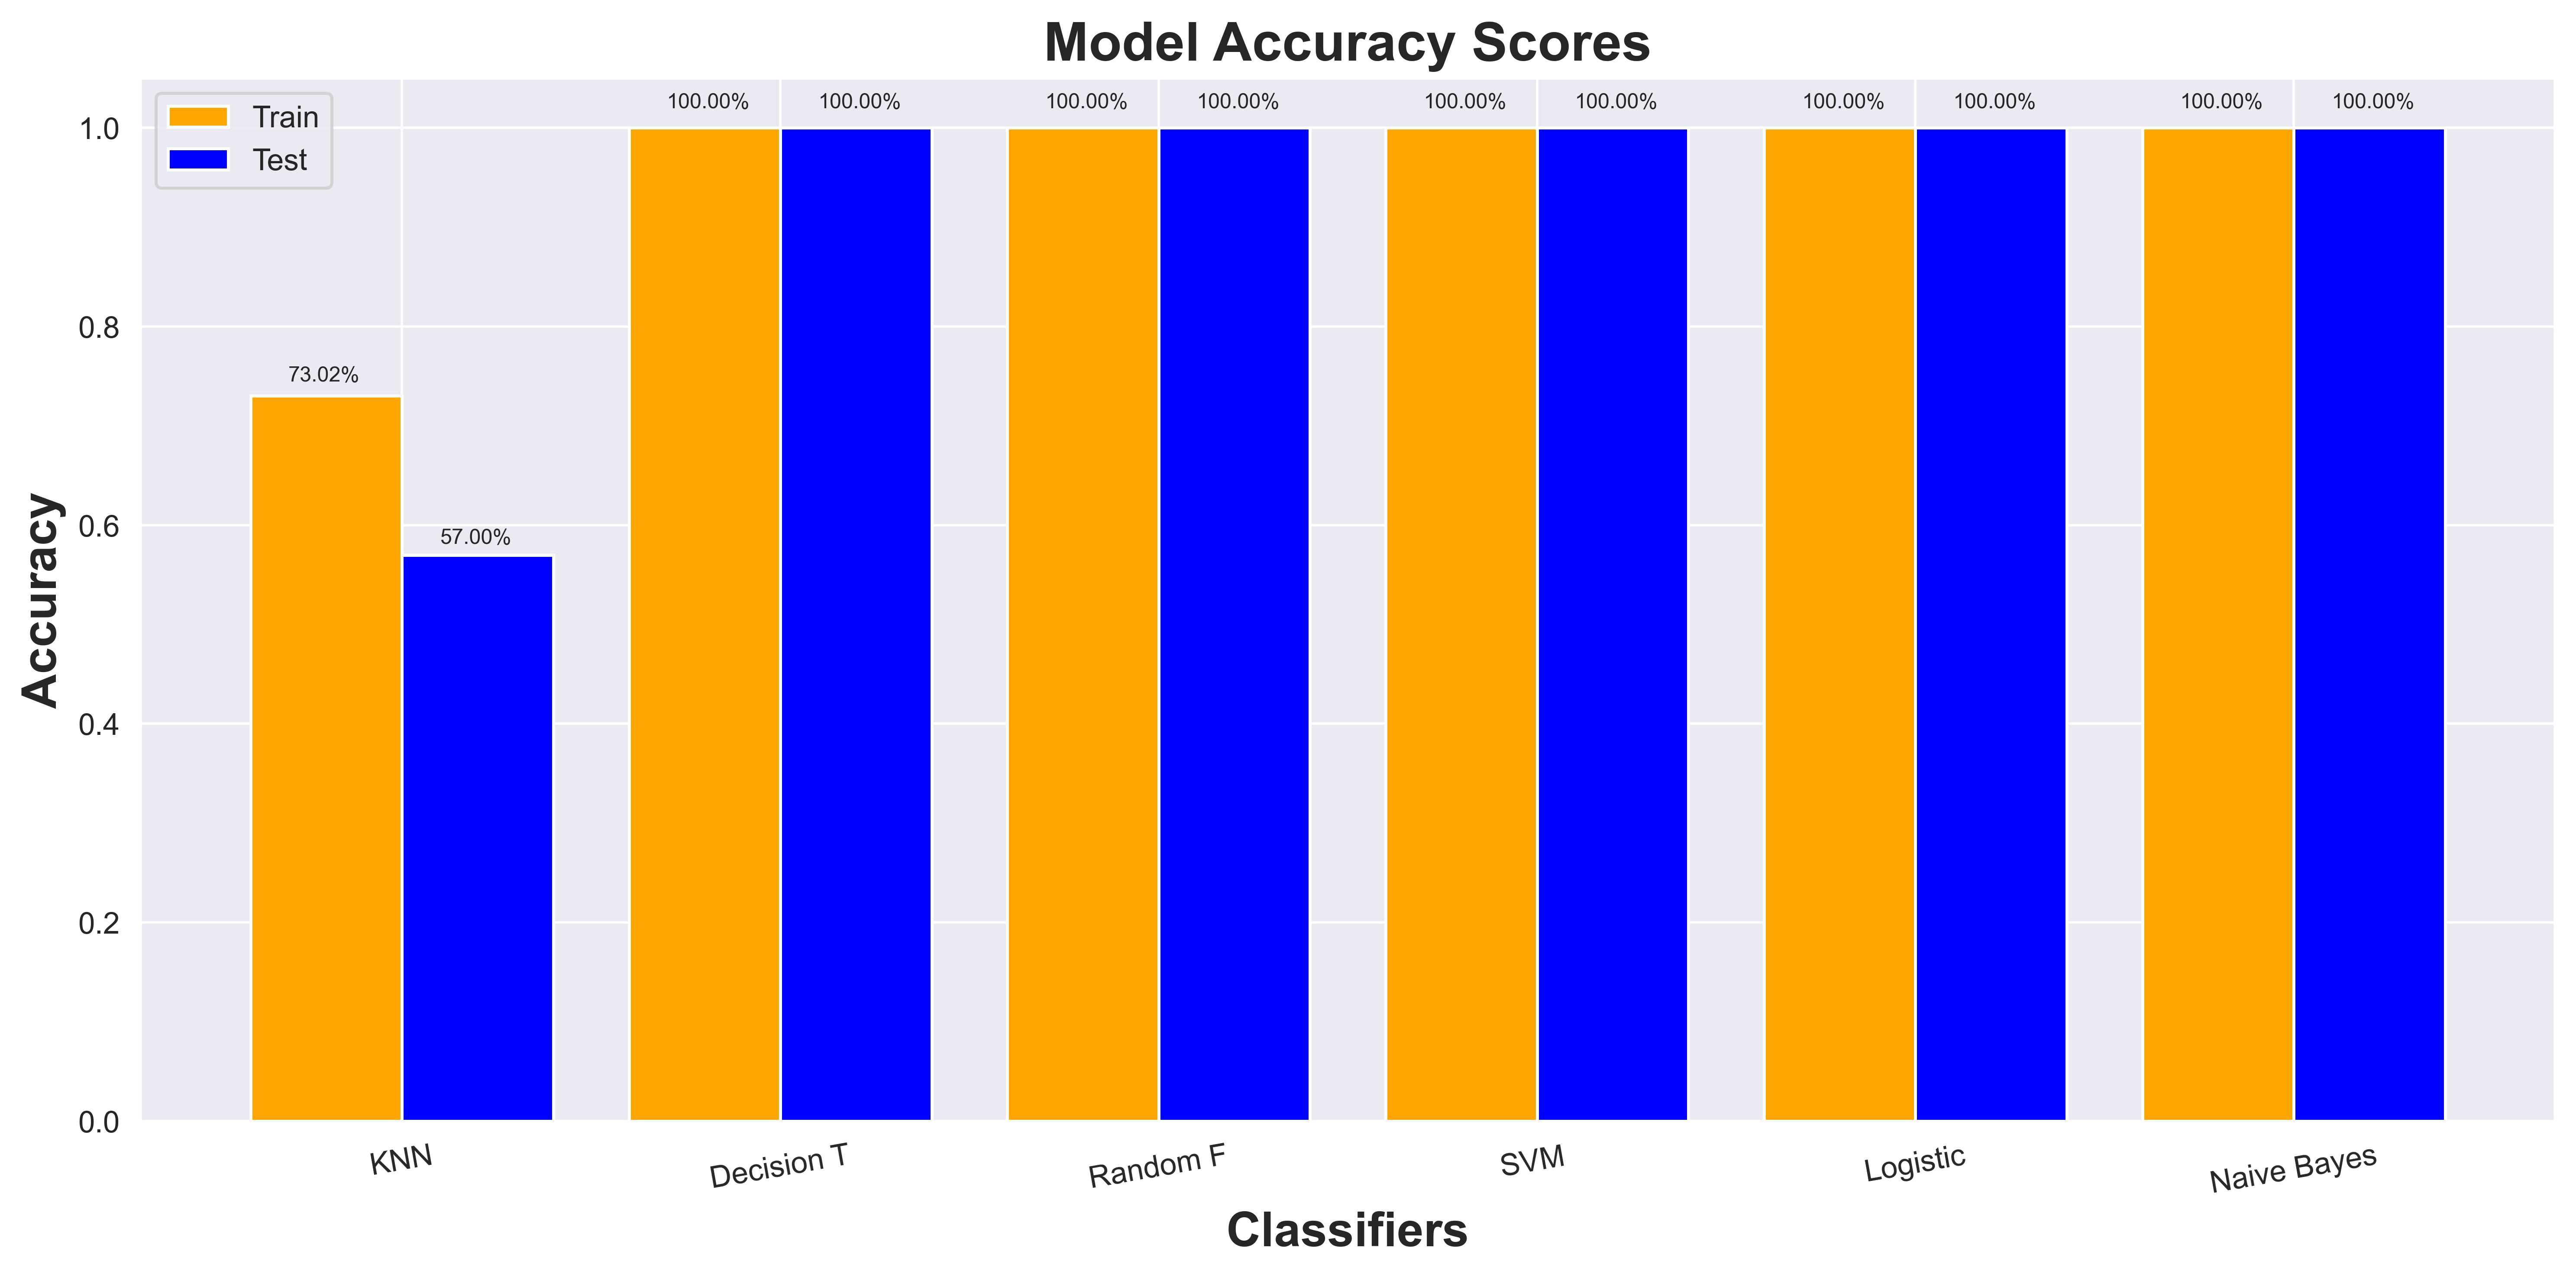

In [40]:
# Train and Test Accuracy plot
import matplotlib.pyplot as plt
import numpy as np

rcParams = {'xtick.labelsize':'12','ytick.labelsize':'14','axes.labelsize':'16'}
fig, axe = plt.subplots(1,1, figsize=(12,6), dpi=500)
x_pos = np.arange(len(table))
model_names = ["KNN", "Decision T", "Random F", "SVM ", "Logistic", "Naive Bayes"]

bar1 = plt.bar(x_pos - 0.2, table['Train_Accuracy(%)'], width=0.4, label='Train', color= "Orange")
bar2 = plt.bar(x_pos + 0.2, table['Test_Accuracy(%)'], width=0.4, label='Test', color= "b")
plt.xticks(x_pos, model_names)

plt.xlabel("Classifiers", fontsize = 16, fontweight = 'bold')
plt.ylabel("Accuracy", fontsize = 16, fontweight = 'bold')
plt.title("Model Accuracy Scores", fontsize = 18, fontweight = 'bold')
plt.xticks(rotation = 10)
plt.legend()

for i, bar in enumerate(bar1):
    plt.text(bar.get_x() + bar.get_width()/2 - 0.1, bar.get_height()*1.02,
             s = '{:.2f}%'.format(Train_accuracies[i]), fontsize = 7)

for i, bar in enumerate(bar2):
    plt.text(bar.get_x() + bar.get_width()/2 - 0.1, bar.get_height()*1.02,
             s = '{:.2f}%'.format(Test_accuracies[i]), fontsize = 7)

pylab.rcParams.update(rcParams)
fig.tight_layout()
plt.show()

Model Deployment

Pickle File

In [41]:
import pickle
filename = 'modelRF.pkl'
pickle.dump(model_RF,open(filename,'wb'))

In [42]:
import pickle
filename = 'vector.pkl'
pickle.dump(tfidf_vector,open(filename,'wb'))